# 10 â€” Robustness, Fairness, and Extensions

Family importance, within-family HP importance (decomposition and V_m-based), and their seed aggregates are maintained in **notebook 06** (`thesis_outputs/tables/nb06/`, `figures/nb06/`).

This notebook covers:

1. **Margin vs variance** â€” are hotspots simply near the decision boundary?
2. **Fairness / subgroup exposure** â€” are HH regions overrepresented for sensitive groups (COMPAS)?
3. **Alternative kNN graph** â€” PCA-reduced and cosine-distance graphs
4. **Auxiliary diagnostics** supporting the final thesis results


In [1]:
import sys
from pathlib import Path

# Robust project-root detection whether launched from repo root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (ROOT / "analysis").exists():
    if (Path.cwd() / "analysis").exists():
        ROOT = Path.cwd()
    elif (Path.cwd().parent / "analysis").exists():
        ROOT = Path.cwd().parent

for p in [str(ROOT), str(ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis.cache import load_or_compute_df
from analysis.fairness import bootstrap_mean_ci, compute_excl_protected, load_fairness_and_perm
from analysis.graph_variants import compute_alt_graph
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.margin import load_margin_and_wilcoxon
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import (
    load_P_test,
    pointwise_variance,
    select_rashomon_global,
    spatial_analysis,
)
from data import load_dataset
from thesis_layout import RAW_RESULTS, display_dataset_name, thesis_figure_dir, thesis_table_dir

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
from scipy import stats

RESULTS = RAW_RESULTS
TABLES = thesis_table_dir("nb10")
FIGURES = thesis_figure_dir("nb10")

K = 25
SEEDS = list(range(10))
DATASETS = ["compas", "german", "adult"]

print(f"ROOT={ROOT}")
_k_str = ", ".join(f"{d}:{K_NN_BY_DATASET[d]}" for d in DATASETS)
print(f"K={K}, k_nn by dataset ({_k_str}), seeds={SEEDS}, datasets={DATASETS}")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


ROOT=c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity
K=25, k_nn by dataset (compas:30, german:30, adult:60), seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], datasets=['compas', 'german', 'adult']


---
## 1. Decision Boundary Analysis: Variance vs Margin

Test if HH points are simply those near `p_mean = 0.5` (low margin).

In [2]:
margin_rows = []
wilcoxon_rows = []


df_margin, df_wilcoxon = load_margin_and_wilcoxon(
    RESULTS, DATASETS, SEEDS, K, CACHE_DIR, CACHE_VERSION, FORCE_RECOMPUTE
)
print(f"Collected {len(df_margin)} margin analysis rows")


Collected 30 margin analysis rows


In [3]:
# Summary table: correlation between variance and margin
agg_margin = df_margin.groupby("dataset").agg(
    pearson_r_mean=("pearson_r", "mean"),
    pearson_r_std=("pearson_r", "std"),
    spearman_r_mean=("spearman_r", "mean"),
    spearman_r_std=("spearman_r", "std"),
    margin_hh_mean=("margin_mean_hh", lambda x: x.dropna().mean()),
    margin_hh_std=("margin_mean_hh", lambda x: x.dropna().std()),
    margin_non_hh_mean=("margin_mean_non_hh", "mean"),
    margin_non_hh_std=("margin_mean_non_hh", "std"),
    margin_hv_mean=("margin_mean_hv", "mean"),
    margin_non_hv_mean=("margin_mean_non_hv", "mean"),
).reset_index()

print("Variance vs Margin correlation (aggregated):")
display(agg_margin)

agg_margin.to_csv(TABLES / "variance_vs_margin_summary.csv", index=False)

Variance vs Margin correlation (aggregated):


,dataset,pearson_r_mean,pearson_r_std,spearman_r_mean,spearman_r_std,margin_hh_mean,margin_hh_std,margin_non_hh_mean,margin_non_hh_std,margin_hv_mean,margin_non_hv_mean
0,adult,-0.331674,0.039044,-0.888616,0.017555,0.199695,0.009780,0.382261,0.005195,0.196331,0.389509
1,compas,-0.043352,0.091062,-0.074199,0.175108,0.187791,0.043919,0.178335,0.004819,0.172169,0.178242
2,german,-0.556165,0.131852,-0.695409,0.103495,0.129683,0.052820,0.259493,0.018379,0.135761,0.269457


In [4]:
# Wilcoxon rank-sum test: margin for HH vs non-HH (per dataset)
if len(df_wilcoxon):
    agg_w = df_wilcoxon.groupby("dataset").agg(
        mean_pval=("p_value", "mean"),
        frac_sig=("p_value", lambda x: (x < 0.05).mean()),
        margin_hh=("margin_hh", "mean"),
        margin_non_hh=("margin_non_hh", "mean"),
    ).reset_index()
    print("Mann-Whitney U: margin(HH) < margin(non-HH)?")
    display(agg_w)
    agg_w.to_csv(TABLES / "margin_hh_wilcoxon.csv", index=False)
else:
    print("No Wilcoxon results.")


Mann-Whitney U: margin(HH) < margin(non-HH)?


,dataset,mean_pval,frac_sig,margin_hh,margin_non_hh
0,adult,5.140725e-60,1.000000,0.199695,0.382261
1,compas,5.315472e-01,0.400000,0.187791,0.178335
2,german,8.000120e-02,0.714286,0.141041,0.259121


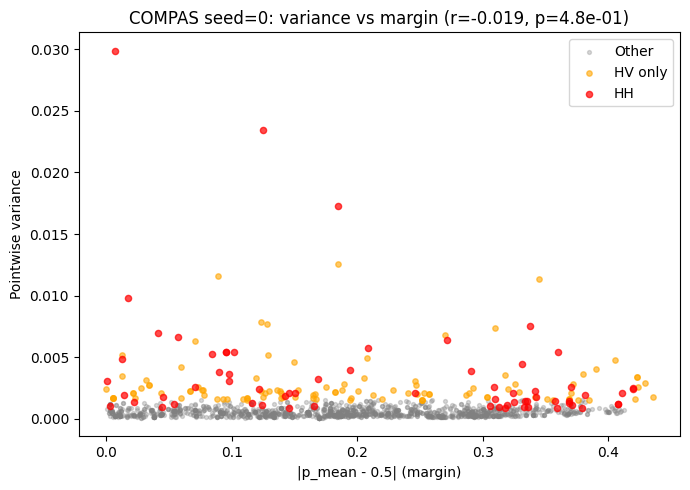

In [5]:
# Scatter plot: variance vs margin for COMPAS seed=0
ds_plot = "compas"
seed_plot = 0
run_dir = RESULTS / ds_plot / f"seed={seed_plot}"

P_test = load_P_test(run_dir)
idx = select_rashomon_global(run_dir, K=K)
P_sel = P_test[idx]
p_mean = P_sel.mean(axis=0)
margin = np.abs(p_mean - 0.5)
v = pointwise_variance(P_sel)

X_test = get_transformed_test_features(run_dir, ds_plot)
sp = spatial_analysis(v, X_test, k=K_NN_BY_DATASET[ds_plot], permutations=999)
hh_mask = sp["HH_mask"]
q90 = np.quantile(v, 0.90)
hv_mask = v >= q90

fig, ax = plt.subplots(figsize=(7, 5))
# Non-hotspot
other = ~hh_mask & ~hv_mask
ax.scatter(margin[other], v[other], s=8, alpha=0.3, c="gray", label="Other")
# HV only
hv_only = hv_mask & ~hh_mask
ax.scatter(margin[hv_only], v[hv_only], s=15, alpha=0.6, c="orange", label="HV only")
# HH
ax.scatter(margin[hh_mask], v[hh_mask], s=20, alpha=0.7, c="red", label="HH")

r, p = stats.pearsonr(v, margin)
ax.set_xlabel("|p_mean - 0.5| (margin)")
ax.set_ylabel("Pointwise variance")
ax.set_title(f"{display_dataset_name(ds_plot)} seed={seed_plot}: variance vs margin (r={r:.3f}, p={p:.1e})")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / f"variance_vs_margin_{ds_plot}.pdf", bbox_inches="tight")
plt.show()

---
## 2. Fairness / Subgroup Exposure (COMPAS)

Are HH/HV regions overrepresented for sensitive groups (race, sex)?

In [6]:
X_raw, y_raw, feature_info = load_dataset("compas")
print(f"COMPAS features: {list(X_raw.columns)}")
print(f"Race values: {X_raw['race'].value_counts().to_dict()}")
print(f"Sex values: {X_raw['sex'].value_counts().to_dict()}")

COMPAS features: ['age', 'priors_count', 'sex', 'race', 'c_charge_degree']
Race values: {'African-American': 3696, 'Caucasian': 2454, 'Hispanic': 637, 'Other': 377, 'Asian': 32, 'Native American': 18}
Sex values: {'Male': 5819, 'Female': 1395}


In [7]:
MIN_GROUP_N = 30      # Minimum per-seed subgroup size for significance reporting
MIN_SEEDS_PER_GROUP = 5
N_PERM = 2000


df_fair, df_perm = load_fairness_and_perm(
    RESULTS, DATASETS, SEEDS, K, CACHE_DIR, CACHE_VERSION, FORCE_RECOMPUTE,
    MIN_GROUP_N, MIN_SEEDS_PER_GROUP, N_PERM
)
print(f"Collected {len(df_fair)} fairness rows")
print(f"Significance threshold: min subgroup size per seed = {MIN_GROUP_N}")


Collected 80 fairness rows
Significance threshold: min subgroup size per seed = 30


In [8]:
# Aggregate: mean Â± std across seeds per group
agg_fair = df_fair.groupby(["group_col", "group_val"]).agg(
    hh_rate_mean=("hh_rate", "mean"),
    hh_rate_std=("hh_rate", "std"),
    mean_var_mean=("mean_variance", "mean"),
    mean_var_std=("mean_variance", "std"),
    n_seeds=("seed", "count"),
    n_seed_eligible=("eligible_sig", "sum"),
    n_group_mean=("n_group", "mean"),
).reset_index()

ci_rows = []
for (group_col, group_val), sub in df_fair.groupby(["group_col", "group_val"]):
    hh_ci_low, hh_ci_high = bootstrap_mean_ci(sub["hh_rate"].values)
    ci_rows.append({
        "group_col": group_col,
        "group_val": group_val,
        "hh_rate_ci_low": hh_ci_low,
        "hh_rate_ci_high": hh_ci_high,
    })

ci_df = pd.DataFrame(ci_rows)
agg_fair = agg_fair.merge(ci_df, on=["group_col", "group_val"], how="left")
agg_fair = agg_fair.sort_values(["group_col", "hh_rate_mean"], ascending=[True, False]).reset_index(drop=True)

print("COMPAS: Group-wise HH rates (mean Â± std across seeds):")
print(f"Eligibility threshold for significance reporting: n_group >= {MIN_GROUP_N} per seed")
display(agg_fair)

agg_fair.to_csv(TABLES / "fairness_subgroup_rates_compas.csv", index=False)

COMPAS: Group-wise HH rates (mean Â± std across seeds):
Eligibility threshold for significance reporting: n_group >= 30 per seed


,group_col,group_val,hh_rate_mean,hh_rate_std,mean_var_mean,mean_var_std,n_seeds,n_seed_eligible,n_group_mean,hh_rate_ci_low,hh_rate_ci_high
0,race,Native American,0.205952,0.312866,0.003647,0.001695,10,0,3.8,0.047619,0.411905
1,race,Asian,0.176310,0.219005,0.004371,0.002060,10,0,6.4,0.057143,0.309527
2,race,Other,0.143309,0.130467,0.001937,0.000477,10,10,71.3,0.077470,0.222364
3,race,African-American,0.114207,0.074978,0.001308,0.000371,10,10,728.9,0.071661,0.157668
4,race,Caucasian,0.056297,0.028272,0.001177,0.000246,10,10,504.5,0.040228,0.072325
5,race,Hispanic,0.035476,0.034982,0.001249,0.000348,10,10,128.1,0.016488,0.056660
6,sex,Male,0.089871,0.046014,0.001277,0.000307,10,10,1164.0,0.063050,0.115379
7,sex,Female,0.085487,0.087433,0.001444,0.000341,10,10,279.0,0.039882,0.136868


In [9]:
print("Stratified permutation test: is HH-rate disparity larger than expected by chance?")
display(df_perm)
df_perm.to_csv(TABLES / "fairness_permutation_test_compas.csv", index=False)


Stratified permutation test: is HH-rate disparity larger than expected by chance?


,group_col,obs_range_stratified,null_range_mean,null_range_std,null_ci_low,null_ci_high,p_value_stratified,n_perm_valid,n_groups_eligible,eligible_groups,min_group_n,min_seeds_per_group,mean_p,obs_range_mean
0,race,0.107833,0.014561,0.007182,0.00389,0.031088,0.000500,2000,4,"African-American, Caucasian, Hispanic, Other",30,5,0.000500,0.107833
1,sex,0.004384,0.004751,0.003568,0.00017,0.013198,0.461769,2000,2,"Female, Male",30,5,0.461769,0.004384


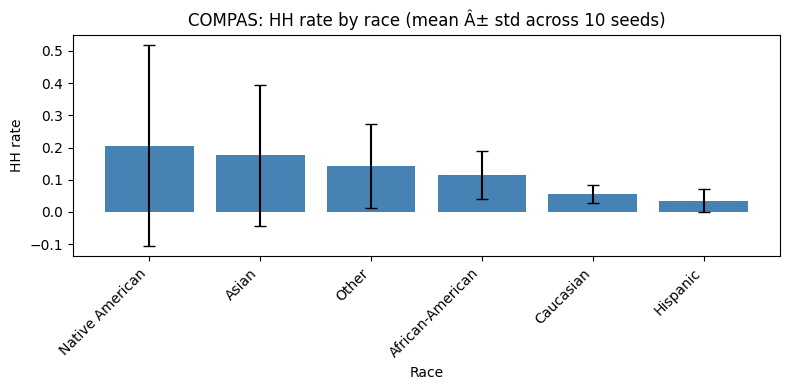

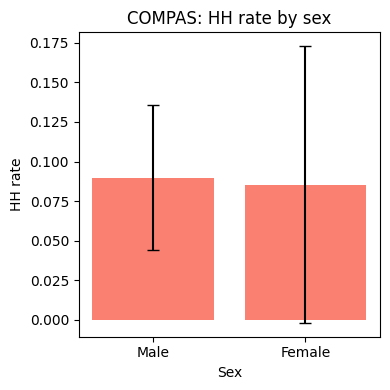

In [10]:
# Bar chart: HH rate by race (with error bars)
race_data = agg_fair[agg_fair["group_col"] == "race"].copy()
race_data = race_data.sort_values("hh_rate_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_data["group_val"], race_data["hh_rate_mean"],
       yerr=race_data["hh_rate_std"], capsize=4, color="steelblue")
ax.set_ylabel("HH rate")
ax.set_xlabel("Race")
ax.set_title("COMPAS: HH rate by race (mean Â± std across 10 seeds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_race_compas.pdf", bbox_inches="tight")
plt.show()

# Sex
sex_data = agg_fair[agg_fair["group_col"] == "sex"].copy()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(sex_data["group_val"], sex_data["hh_rate_mean"],
       yerr=sex_data["hh_rate_std"], capsize=4, color="salmon")
ax.set_ylabel("HH rate")
ax.set_xlabel("Sex")
ax.set_title("COMPAS: HH rate by sex")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_sex_compas.pdf", bbox_inches="tight")
plt.show()

In [11]:
df_excl = load_or_compute_df(
    CACHE_DIR / f"nb10_excl_protected_{CACHE_VERSION}.parquet",
    lambda: compute_excl_protected(RESULTS, DATASETS, SEEDS, K, CACHE_DIR, CACHE_VERSION),
    force=FORCE_RECOMPUTE,
)
print("kNN graph: full features vs. excluding race/sex (COMPAS)")
print(f"  Moran I   full: {df_excl['moran_full'].mean():.3f} +/- {df_excl['moran_full'].std():.3f}")
print(f"  Moran I   excl: {df_excl['moran_excl_prot'].mean():.3f} +/- {df_excl['moran_excl_prot'].std():.3f}")
print(f"  n_HH      full: {df_excl['n_hh_full'].mean():.1f} +/- {df_excl['n_hh_full'].std():.1f}")
print(f"  n_HH      excl: {df_excl['n_hh_excl_prot'].mean():.1f} +/- {df_excl['n_hh_excl_prot'].std():.1f}")
print(f"  Jaccard HH:     {df_excl['jaccard_hh'].mean():.3f} +/- {df_excl['jaccard_hh'].std():.3f}")
df_excl.to_csv(TABLES / "knn_excl_protected_compas.csv", index=False)


kNN graph: full features vs. excluding race/sex (COMPAS)
  Moran I   full: 0.210 +/- 0.081
  Moran I   excl: 0.256 +/- 0.090
  n_HH      full: 128.4 +/- 73.6
  n_HH      excl: 158.0 +/- 61.4
  Jaccard HH:     0.518 +/- 0.108


---
## 3. Alternative kNN Graph Constructions

Test whether spatial results depend on the distance metric / representation.

In [12]:
alt_rows = []


df_alt = load_or_compute_df(
    CACHE_DIR / f"nb10_alt_graph_{CACHE_VERSION}.parquet",
    lambda: compute_alt_graph(RESULTS, DATASETS, SEEDS, K, CACHE_DIR, CACHE_VERSION),
    force=FORCE_RECOMPUTE,
)
print(f"\nCollected {len(df_alt)} alternative graph rows")



Collected 90 alternative graph rows


In [13]:
# Summary table: mean Â± std per method per dataset
agg_alt = df_alt.groupby(["dataset", "method"]).agg(
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    hh_mean=("n_hh", "mean"),
    hh_std=("n_hh", "std"),
    n_seeds=("seed", "count"),
).reset_index()

print("Alternative kNN graph comparison (mean Â± std across seeds):")
display(agg_alt)

agg_alt.to_csv(TABLES / "alternative_knn_comparison.csv", index=False)

Alternative kNN graph comparison (mean Â± std across seeds):


,dataset,method,moran_mean,moran_std,hh_mean,hh_std,n_seeds
0,adult,cosine,0.079687,0.021787,698.4,217.707857,10
1,adult,euclidean,0.074933,0.021909,631.0,239.746162,10
2,adult,pca_5,0.072884,0.023157,694.3,239.855998,10
3,compas,cosine,0.213200,0.087428,149.3,73.160478,10
4,compas,euclidean,0.210018,0.081427,128.4,73.646604,10
5,compas,pca_5,0.212461,0.084544,140.4,73.910156,10
6,german,cosine,0.096489,0.040517,7.9,6.436873,10
7,german,euclidean,0.087606,0.038775,5.4,5.378971,10
8,german,pca_5,0.051327,0.035498,4.7,5.457920,10


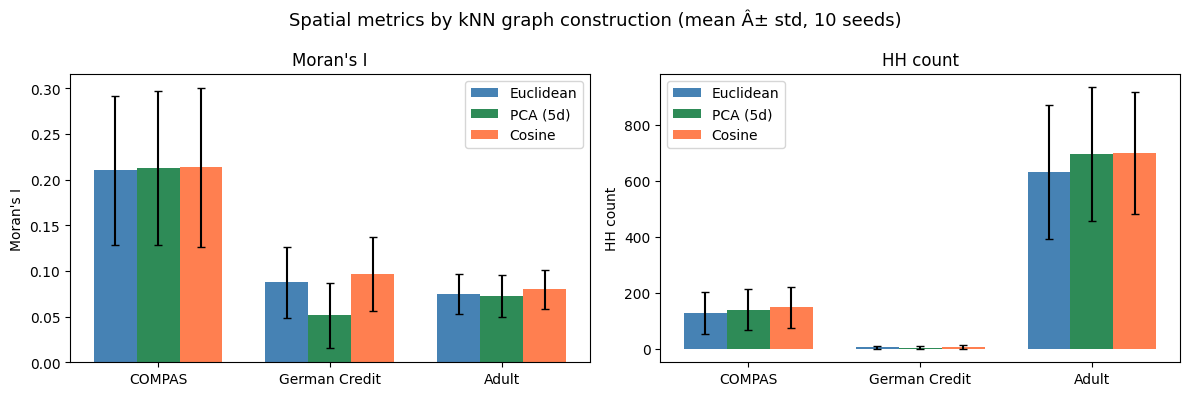

In [14]:
# Grouped bar plot: Moran's I by method for each dataset
methods = ["euclidean", "pca_5", "cosine"]
method_labels = ["Euclidean", "PCA (5d)", "Cosine"]
colors = ["steelblue", "seagreen", "coral"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, metric in enumerate(["moran_i", "n_hh"]):
    ax = axes[ax_idx]
    x = np.arange(len(DATASETS))
    width = 0.25
    
    for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
        sub = agg_alt[agg_alt["method"] == method]
        means = []
        stds = []
        for ds in DATASETS:
            row = sub[sub["dataset"] == ds]
            if len(row):
                col_mean = "moran_mean" if metric == "moran_i" else "hh_mean"
                col_std = "moran_std" if metric == "moran_i" else "hh_std"
                means.append(row[col_mean].values[0])
                stds.append(row[col_std].values[0])
            else:
                means.append(0)
                stds.append(0)
        
        ax.bar(x + i * width, means, width, yerr=stds, label=label,
               color=color, capsize=3)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels([display_dataset_name(d) for d in DATASETS])
    ax.set_ylabel("Moran's I" if metric == "moran_i" else "HH count")
    ax.set_title("Moran's I" if metric == "moran_i" else "HH count")
    ax.legend()

fig.suptitle("Spatial metrics by kNN graph construction (mean Â± std, 10 seeds)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "alternative_knn_comparison.pdf", bbox_inches="tight")
plt.show()

## 4. Appendix tables: conflict metrics and quadrant analysis

Matches appendix Tables `app-conflict-metrics` and `app-conflict-quadrants`.


In [15]:
from scripts.export_thesis_assets import SUPPORTED_DATASETS

# Conflict metrics by dataset (appendix Table app-conflict-metrics)
_conflict_rows = []
for ds in SUPPORTED_DATASETS:
    path = RESULTS / ds / "summary_per_run.csv"
    if not path.is_file():
        continue
    df = pd.read_csv(path)
    n = len(df)
    ddof = 1 if n > 1 else 0
    _conflict_rows.append({
        "Dataset": display_dataset_name(ds),
        "Mean c_i": f"{df['mean_conflict'].mean():.3f} ± {df['mean_conflict'].std(ddof=ddof):.3f}",
        "c_i > 0 (%)": f"{100 * df['frac_conflict_gt0'].mean():.1f} ± {100 * df['frac_conflict_gt0'].std(ddof=ddof):.1f}",
        "c_i >= 0.25 (%)": f"{100 * df['frac_conflict_ge025'].mean():.1f} ± {100 * df['frac_conflict_ge025'].std(ddof=ddof):.1f}",
        "Conflict Moran's I": f"{df['conflict_moran_i'].mean():.2f} ± {df['conflict_moran_i'].std(ddof=ddof):.2f}",
        "Conflict HH": f"{df['conflict_n_hh'].mean():.1f} ± {df['conflict_n_hh'].std(ddof=ddof):.1f}",
    })
print("Appendix table: conflict metrics by dataset")
display(pd.DataFrame(_conflict_rows))

# COMPAS quadrant breakdown (appendix Table app-conflict-quadrants)
_qpath = RESULTS / "compas" / "quadrant_breakdown_aggregated.csv"
if _qpath.is_file():
    _qdf = pd.read_csv(_qpath)
    _labels = {
        "A": "A (high var, high conflict)",
        "B": "B (high var, low conflict)",
        "C": "C (low var, high conflict)",
        "D": "D (low var, low conflict)",
    }
    _qrows = []
    for q in ["A", "B", "C", "D"]:
        r = _qdf[_qdf["quadrant"] == q].iloc[0]
        _qrows.append({
            "Quadrant": _labels[q],
            "N observations": f"{r['count_mean']:.1f} ± {r['count_std']:.1f}",
            "Share of test": f"{100 * r['fraction_mean']:.1f}% ± {100 * r['fraction_std']:.1f}%",
            "Mean variance v_i": f"{r['mean_var_p_mean']:.4f} ± {r['mean_var_p_std']:.4f}",
            "Mean conflict c_i": f"{r['mean_conflict_mean']:.3f} ± {r['mean_conflict_std']:.3f}",
        })
    print("Appendix table: COMPAS variance–conflict quadrant breakdown")
    display(pd.DataFrame(_qrows))
else:
    print("Missing results/compas/quadrant_breakdown_aggregated.csv")


Appendix table: conflict metrics by dataset


,Dataset,Mean c_i,c_i > 0 (%),c_i >= 0.25 (%),Conflict Moran's I,Conflict HH
0,COMPAS,0.035 ± 0.007,17.9 ± 2.9,5.9 ± 1.6,0.17 ± 0.03,122.0 ± 23.4
1,German Credit,0.059 ± 0.022,30.1 ± 8.5,9.8 ± 4.6,0.05 ± 0.03,1.3 ± 2.4
2,Adult,0.017 ± 0.001,9.5 ± 0.5,2.7 ± 0.2,0.12 ± 0.01,627.1 ± 59.9


Appendix table: COMPAS variance–conflict quadrant breakdown


,Quadrant,N observations,Share of test,Mean variance v_i,Mean conflict c_i
0,"A (high var, high conflict)",33.9 ± 8.2,2.3% ± 0.6%,0.0068 ± 0.0017,0.290 ± 0.057
1,"B (high var, low conflict)",111.6 ± 8.1,7.7% ± 0.6%,0.0043 ± 0.0012,0.010 ± 0.007
2,"C (low var, high conflict)",125.3 ± 10.0,8.7% ± 0.7%,0.0011 ± 0.0003,0.278 ± 0.051
3,"D (low var, low conflict)",1172.2 ± 9.9,81.2% ± 0.7%,0.0009 ± 0.0002,0.005 ± 0.003


Family / HP driver outputs: see **notebook 06** (`thesis_outputs/tables/nb06/`, `figures/nb06/`).

---
## Summary

Saved tables:
- `thesis_outputs/tables/nb10/variance_vs_margin_summary.csv`
- `thesis_outputs/tables/nb10/margin_hh_wilcoxon.csv`
- `thesis_outputs/tables/nb10/fairness_subgroup_rates_compas.csv`
- `thesis_outputs/tables/nb10/fairness_permutation_test_compas.csv`
- `thesis_outputs/tables/nb10/alternative_knn_comparison.csv`

Saved figures:
- `thesis_outputs/figures/nb10/variance_vs_margin_compas.pdf`
- `thesis_outputs/figures/nb10/fairness_hh_rate_by_race_compas.pdf`
- `thesis_outputs/figures/nb10/fairness_hh_rate_by_sex_compas.pdf`
- `thesis_outputs/figures/nb10/alternative_knn_comparison.pdf`